### Import

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
df = pd.read_csv("../data/atms_data.csv")
df

,Unnamed: 0,Date,ATM_ID,Number_of_Trxs,Amount,capacity,Weekday,Working_day
0,0,20180201,3479212,199,235250,NaN,Thursday,Yes
1,1,20180201,1599756,105,237300,NaN,Thursday,Yes
2,2,20180201,2019227,487,539910,720000.0,Thursday,Yes
3,3,20180201,3200101,354,466900,NaN,Thursday,Yes
4,4,20180201,5129042,224,432610,NaN,Thursday,Yes
...,...,...,...,...,...,...,...,...
573114,573114,20181231,3749381,5,10800,NaN,Monday,Yes
573115,573115,20181231,2020290,44,46300,720000.0,Monday,Yes
573116,573116,20181231,4009162,1,200,900000.0,Monday,Yes
573117,573117,20181231,3149289,4,8800,900000.0,Monday,Yes


In [45]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y%m%d")
df["ATM_ID"] = df["ATM_ID"].astype("category")
df = df.sort_values(["ATM_ID", "Date"])
df

,Unnamed: 0,Date,ATM_ID,Number_of_Trxs,Amount,capacity,Weekday,Working_day
21549,21549,2018-02-01,1009104,141,213550,NaN,Thursday,Yes
21806,21806,2018-02-02,1009104,7,2570,NaN,Friday,No
7903,7903,2018-02-04,1009104,129,210980,NaN,Sunday,Yes
15458,15458,2018-02-05,1009104,121,215190,NaN,Monday,Yes
1366,1366,2018-02-06,1009104,101,152900,NaN,Tuesday,Yes
...,...,...,...,...,...,...,...,...
506894,506894,2018-12-27,7089115,30,38800,NaN,Thursday,Yes
535310,535310,2018-12-28,7089115,28,45290,NaN,Friday,No
506973,506973,2018-12-29,7089115,71,94670,NaN,Saturday,No
526663,526663,2018-12-30,7089115,70,126030,NaN,Sunday,Yes


### Feature Extraction

Drop unnecesarry columns
- "Unnamed: 0" is just index number
- "Weekday" is the dayofweek which can be derived from Date later

In [46]:
df = df.drop(columns=["Unnamed: 0", "Weekday"])

In [47]:
df["Working_day"] = df["Working_day"].map({
    "Yes": 1,
    "No": 0
})

In [48]:
# Basic info
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofweek"] = df["Date"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)

# Lag features
LAGS = [1, 2, 3, 7, 14, 28]

for lag in LAGS:
    df[f"lag_{lag}"] = (
        df.groupby("ATM_ID")["Amount"].shift(lag)
    )

# Windows features
WINDOWS = [7, 14, 28]

for w in WINDOWS:
    df[f"rolling_mean_{w}"] = (
        df.groupby("ATM_ID")["Amount"]
          .shift(1)
          .rolling(w)
          .mean()
          .reset_index(level=0, drop=True)
    )
    df[f"rolling_std_{w}"] = (
        df.groupby("ATM_ID")["Amount"]
          .shift(1)
          .rolling(w)
          .std()
          .reset_index(level=0, drop=True)
    )
    df[f"rolling_min_{w}"] = (
        df.groupby("ATM_ID")["Amount"]
          .shift(1)
          .rolling(w)
          .min()
          .reset_index(level=0, drop=True)
    )
    df[f"rolling_max_{w}"] = (
        df.groupby("ATM_ID")["Amount"]
          .shift(1)
          .rolling(w)
          .max()
          .reset_index(level=0, drop=True)
    )

# Exponentially Weigthed Mean Features
df["ewm_7"] = (
    df.groupby("ATM_ID")["Amount"]
      .shift(1)
      .ewm(span=7)
      .mean()
      .reset_index(level=0, drop=True)
)

df["ewm_28"] = (
    df.groupby("ATM_ID")["Amount"]
      .shift(1)
      .ewm(span=28)
      .mean()
      .reset_index(level=0, drop=True)
)

# Difference/Momentum Features
df["diff_1"] = df["lag_1"] - df["lag_2"]
df["diff_7"] = df["lag_7"] - df["lag_14"]

df["pct_change_1"] = (
    df.groupby("ATM_ID")["Amount"].pct_change(1)
)

# Cyclical Encoding
df["dow_sin"] = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["dayofweek"]/7)

# Expanding Mean
df["expanding_mean"] = (
    df.groupby("ATM_ID")["Amount"]
      .shift(1)
      .expanding()
      .mean()
      .reset_index(level=0, drop=True)
)

# Average withdrawal
df["avg_withdrawal"] = df["Amount"] / df["Number_of_Trxs"]
df["avg_withdrawal_lag1"] = (
    df.groupby("ATM_ID")["avg_withdrawal"].shift(1)
)
df = df.drop(columns="avg_withdrawal")

df

C:\Users\leonardo\AppData\Local\Temp\ipykernel_16124\591863566.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ATM_ID")["Amount"].shift(lag)
C:\Users\leonardo\AppData\Local\Temp\ipykernel_16124\591863566.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ATM_ID")["Amount"].shift(lag)
C:\Users\leonardo\AppData\Local\Temp\ipykernel_16124\591863566.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this war

,Date,ATM_ID,Number_of_Trxs,Amount,capacity,Working_day,month,day,dayofweek,is_weekend,...,rolling_max_28,ewm_7,ewm_28,diff_1,diff_7,pct_change_1,dow_sin,dow_cos,expanding_mean,avg_withdrawal_lag1
21549,2018-02-01,1009104,141,213550,NaN,1,2,1,3,0,...,600320.0,343265.694563,324517.107221,NaN,NaN,NaN,0.433884,-0.900969,202517.730705,NaN
21806,2018-02-02,1009104,7,2570,NaN,0,2,2,4,0,...,481600.0,222822.276061,228471.513670,NaN,NaN,-0.987965,-0.433884,-0.900969,204171.534635,1514.539007
7903,2018-02-04,1009104,129,210980,NaN,1,2,4,6,1,...,NaN,174022.582431,184772.333121,-210980.0,NaN,81.093385,-0.781831,0.623490,186517.106734,367.142857
15458,2018-02-05,1009104,121,215190,NaN,1,2,5,0,0,...,371090.0,183271.259236,105500.693081,208410.0,NaN,0.019954,0.000000,1.000000,166423.354990,1635.503876
1366,2018-02-06,1009104,101,152900,NaN,1,2,6,1,0,...,873020.0,385099.779055,384685.628579,4210.0,NaN,-0.289465,0.781831,0.623490,199425.650257,1778.429752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506894,2018-12-27,7089115,30,38800,NaN,1,12,27,3,0,...,52150.0,27453.384175,33857.610754,-94060.0,25470.0,-0.348993,0.433884,-0.900969,215969.466795,1295.652174
535310,2018-12-28,7089115,28,45290,NaN,0,12,28,4,0,...,137870.0,59495.091382,62222.557589,-20800.0,4350.0,0.167268,-0.433884,-0.900969,213837.665016,1293.333333
506973,2018-12-29,7089115,71,94670,NaN,0,12,29,5,1,...,58100.0,27229.369678,28058.456161,6490.0,-2770.0,1.090307,-0.974928,-0.222521,215939.540442,1617.500000
526663,2018-12-30,7089115,70,126030,NaN,1,12,30,6,1,...,250690.0,105513.391381,113068.587493,49380.0,29900.0,0.331256,-0.781831,0.623490,213713.018465,1333.380282


### Structure and Sanity

In [49]:
df.shape

(573119, 37)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 573119 entries, 21549 to 553360
Data columns (total 37 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Date                 573119 non-null  datetime64[ns]
 1   ATM_ID               573119 non-null  category      
 2   Number_of_Trxs       573119 non-null  int64         
 3   Amount               573119 non-null  int64         
 4   capacity             143996 non-null  float64       
 5   Working_day          573119 non-null  int64         
 6   month                573119 non-null  int32         
 7   day                  573119 non-null  int32         
 8   dayofweek            573119 non-null  int32         
 9   is_weekend           573119 non-null  int64         
 10  lag_1                570425 non-null  float64       
 11  lag_2                567733 non-null  float64       
 12  lag_3                565047 non-null  float64       
 13  lag_7          

### Null and Duplicated Check

In [51]:
df.isna().sum()

Date                        0
ATM_ID                      0
Number_of_Trxs              0
Amount                      0
capacity               429123
Working_day                 0
month                       0
day                         0
dayofweek                   0
is_weekend                  0
lag_1                    2694
lag_2                    5386
lag_3                    8072
lag_7                   18795
lag_14                  37348
lag_28                  73919
rolling_mean_7          18795
rolling_std_7           18795
rolling_min_7           18795
rolling_max_7           18795
rolling_mean_14         37348
rolling_std_14          37348
rolling_min_14          37348
rolling_max_14          37348
rolling_mean_28         73919
rolling_std_28          73919
rolling_min_28          73919
rolling_max_28          73919
ewm_7                       1
ewm_28                      1
diff_1                   5386
diff_7                  37348
pct_change_1             2694
dow_sin   

In [52]:
df["capacity_missing"] = df["capacity"].isna().astype(int)
df["capacity"] = df["capacity"].fillna(df["capacity"].median())

df

,Date,ATM_ID,Number_of_Trxs,Amount,capacity,Working_day,month,day,dayofweek,is_weekend,...,ewm_7,ewm_28,diff_1,diff_7,pct_change_1,dow_sin,dow_cos,expanding_mean,avg_withdrawal_lag1,capacity_missing
21549,2018-02-01,1009104,141,213550,900000.0,1,2,1,3,0,...,343265.694563,324517.107221,NaN,NaN,NaN,0.433884,-0.900969,202517.730705,NaN,1
21806,2018-02-02,1009104,7,2570,900000.0,0,2,2,4,0,...,222822.276061,228471.513670,NaN,NaN,-0.987965,-0.433884,-0.900969,204171.534635,1514.539007,1
7903,2018-02-04,1009104,129,210980,900000.0,1,2,4,6,1,...,174022.582431,184772.333121,-210980.0,NaN,81.093385,-0.781831,0.623490,186517.106734,367.142857,1
15458,2018-02-05,1009104,121,215190,900000.0,1,2,5,0,0,...,183271.259236,105500.693081,208410.0,NaN,0.019954,0.000000,1.000000,166423.354990,1635.503876,1
1366,2018-02-06,1009104,101,152900,900000.0,1,2,6,1,0,...,385099.779055,384685.628579,4210.0,NaN,-0.289465,0.781831,0.623490,199425.650257,1778.429752,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506894,2018-12-27,7089115,30,38800,900000.0,1,12,27,3,0,...,27453.384175,33857.610754,-94060.0,25470.0,-0.348993,0.433884,-0.900969,215969.466795,1295.652174,1
535310,2018-12-28,7089115,28,45290,900000.0,0,12,28,4,0,...,59495.091382,62222.557589,-20800.0,4350.0,0.167268,-0.433884,-0.900969,213837.665016,1293.333333,1
506973,2018-12-29,7089115,71,94670,900000.0,0,12,29,5,1,...,27229.369678,28058.456161,6490.0,-2770.0,1.090307,-0.974928,-0.222521,215939.540442,1617.500000,1
526663,2018-12-30,7089115,70,126030,900000.0,1,12,30,6,1,...,105513.391381,113068.587493,49380.0,29900.0,0.331256,-0.781831,0.623490,213713.018465,1333.380282,1


In [53]:
df.isna().sum()

Date                       0
ATM_ID                     0
Number_of_Trxs             0
Amount                     0
capacity                   0
Working_day                0
month                      0
day                        0
dayofweek                  0
is_weekend                 0
lag_1                   2694
lag_2                   5386
lag_3                   8072
lag_7                  18795
lag_14                 37348
lag_28                 73919
rolling_mean_7         18795
rolling_std_7          18795
rolling_min_7          18795
rolling_max_7          18795
rolling_mean_14        37348
rolling_std_14         37348
rolling_min_14         37348
rolling_max_14         37348
rolling_mean_28        73919
rolling_std_28         73919
rolling_min_28         73919
rolling_max_28         73919
ewm_7                      1
ewm_28                     1
diff_1                  5386
diff_7                 37348
pct_change_1            2694
dow_sin                    0
dow_cos       

In [54]:
df_model = df.dropna()
print(df_model.isna().sum().sum())
print(df_model.shape)

0
(434362, 38)


In [55]:
df_model = df_model.sort_values(["ATM_ID", "Date"]).reset_index(drop=True)
df_model["amount_per_capacity"] = df_model["lag_1"] / df_model["capacity"]
df_model

,Date,ATM_ID,Number_of_Trxs,Amount,capacity,Working_day,month,day,dayofweek,is_weekend,...,ewm_28,diff_1,diff_7,pct_change_1,dow_sin,dow_cos,expanding_mean,avg_withdrawal_lag1,capacity_missing,amount_per_capacity
0,2018-03-05,1009104,146,241200,900000.0,1,3,5,0,0,...,111484.853951,51970.0,-400.0,1.938596,0.000000,1.000000,241934.031165,1520.000000,1,0.091200
1,2018-03-06,1009104,133,200020,900000.0,1,3,6,1,0,...,62339.784664,159120.0,1870.0,-0.170730,0.781831,0.623490,218374.089773,1652.054795,1,0.268000
2,2018-03-07,1009104,131,180760,900000.0,1,3,7,2,0,...,36530.425980,-41180.0,396980.0,-0.096290,0.974928,-0.222521,232292.564130,1503.909774,1,0.222244
3,2018-03-08,1009104,123,103320,900000.0,1,3,8,3,0,...,432759.652199,-19260.0,367540.0,-0.428413,0.433884,-0.900969,229704.125018,1379.847328,1,0.200844
4,2018-03-11,1009104,153,341030,900000.0,1,3,11,6,1,...,210191.350196,-19710.0,-60600.0,479.323944,-0.781831,0.623490,219632.609955,236.666667,1,0.000789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434357,2018-12-27,7089115,30,38800,900000.0,1,12,27,3,0,...,33857.610754,-94060.0,25470.0,-0.348993,0.433884,-0.900969,215969.466795,1295.652174,1,0.066222
434358,2018-12-28,7089115,28,45290,900000.0,0,12,28,4,0,...,62222.557589,-20800.0,4350.0,0.167268,-0.433884,-0.900969,213837.665016,1293.333333,1,0.043111
434359,2018-12-29,7089115,71,94670,900000.0,0,12,29,5,1,...,28058.456161,6490.0,-2770.0,1.090307,-0.974928,-0.222521,215939.540442,1617.500000,1,0.050322
434360,2018-12-30,7089115,70,126030,900000.0,1,12,30,6,1,...,113068.587493,49380.0,29900.0,0.331256,-0.781831,0.623490,213713.018465,1333.380282,1,0.105189


### Statistic Analysis

In [56]:
df_model.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,434362,2018-08-16 05:50:07.738246400,2018-03-01 00:00:00,2018-06-04 00:00:00,2018-09-04 00:00:00,2018-11-05 00:00:00,2018-12-31 00:00:00,NaN
Number_of_Trxs,434362.0,139.025209,1.0,48.0,110.0,196.0,1183.0,120.044085
Amount,434362.0,213502.196923,10.0,59880.0,154430.0,298527.5,2508470.0,211972.29801
capacity,434362.0,906617.084367,530000.0,900000.0,900000.0,900000.0,1700000.0,97090.906988
Working_day,434362.0,0.72437,0.0,0.0,1.0,1.0,1.0,0.446831
month,434362.0,8.012566,3.0,6.0,9.0,11.0,12.0,2.926688
day,434362.0,15.915856,1.0,8.0,16.0,24.0,31.0,8.824301
dayofweek,434362.0,2.975449,0.0,1.0,3.0,5.0,6.0,2.008409
is_weekend,434362.0,0.284007,0.0,0.0,0.0,1.0,1.0,0.450941
lag_1,434362.0,213624.552102,10.0,59800.0,154350.0,298690.0,2508470.0,212348.016467


In [57]:
df_model.describe(exclude="number").T

,count,unique,top,freq,mean,min,25%,50%,75%,max
Date,434362,NaN,NaN,NaN,2018-08-16 05:50:07.738246400,2018-03-01 00:00:00,2018-06-04 00:00:00,2018-09-04 00:00:00,2018-11-05 00:00:00,2018-12-31 00:00:00
ATM_ID,434362.0,2576.0,1109506.0,230.0,NaN,NaN,NaN,NaN,NaN,NaN


### Feature Outliers Handling

In [58]:
df_model["pct_change_1"] = df_model["pct_change_1"].clip(-5, 5)

### Training Preparation

In [59]:
target = "Amount"

X = df_model.drop(columns=[target, "Number_of_Trxs", "Date", "ATM_ID"])
y = np.log1p(df_model["Amount"])

X.shape, y.shape

((434362, 35), (434362,))

In [60]:
split_date = "2018-11-01"

train_idx = df_model["Date"] < split_date
test_idx  = df_model["Date"] >= split_date

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

In [61]:
linreg_features = [
    # strong linear drivers
    "Number_of_Trxs",
    "lag_1",
    "lag_7",
    "lag_28",

    # smooth trend (choose ONE type)
    "rolling_mean_7",

    # volatility (one is enough)
    "rolling_std_7",

    # calendar effects
    "Working_day",
    "dow_sin",
    "dow_cos",

    # ATM structure
    "capacity",
    "capacity_missing",

    # behavior signal
    "avg_withdrawal_lag1",
    "amount_per_capacity"
]

X_linreg = df_model[linreg_features + ["ATM_ID"]]
X_linreg = pd.get_dummies(X_linreg, columns=["ATM_ID"], drop_first=True)

X_train_lin = X.loc[train_idx]
X_test_lin = X.loc[test_idx]

### Model

In [62]:
def evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    pred = np.expm1(pred_log)
    y_true = np.expm1(y_test)

    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2 = r2_score(y_true, pred)

    print(f"\n{name}")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²  : {r2:.4f}")

In [63]:
linreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

evaluate(linreg, X_train_lin, y_train, X_test_lin, y_test, "Linear Regression")


Linear Regression
MAE : 135,127.65
RMSE: 676,085.85
R²  : -9.2739


In [64]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

evaluate(rf, X_train, y_train, X_test, y_test, "Random Forest")


Random Forest
MAE : 6,298.19
RMSE: 34,427.01
R²  : 0.9734


In [65]:
xgb = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42
    )


evaluate(xgb, X_train, y_train, X_test, y_test, "XGBoost")


XGBoost
MAE : 8,246.34
RMSE: 36,447.62
R²  : 0.9701


### Evaluation

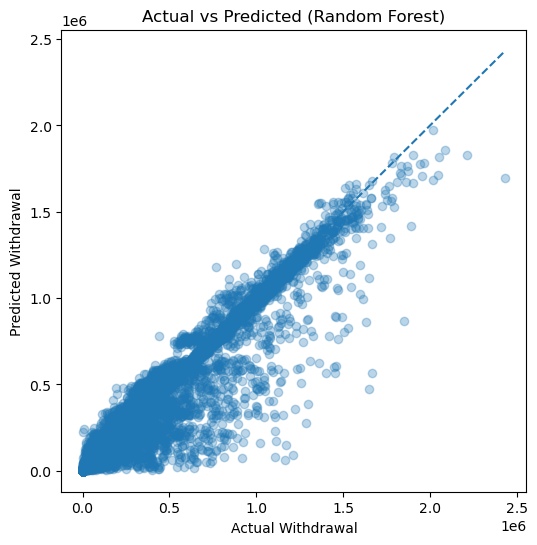

In [66]:
pred_log = rf.predict(X_test)

pred = np.expm1(pred_log)
y_true = np.expm1(y_test)

plt.figure(figsize=(6,6))
plt.scatter(y_true, pred, alpha=0.3)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    linestyle="--"
)

plt.xlabel("Actual Withdrawal")
plt.ylabel("Predicted Withdrawal")
plt.title("Actual vs Predicted (Random Forest)")

plt.show()

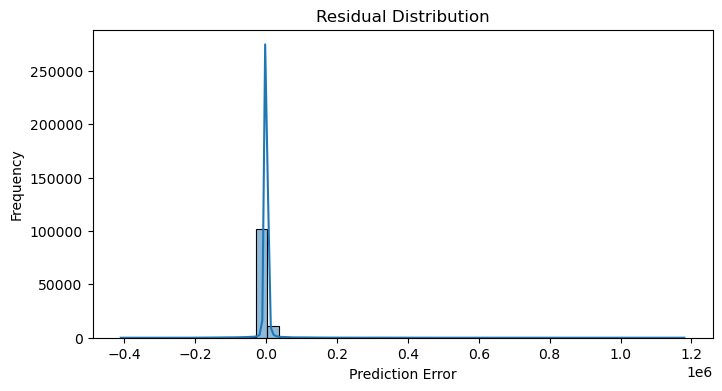

In [67]:
residuals = y_true - pred

plt.figure(figsize=(8,4))
sns.histplot(residuals, bins=50, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [72]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
6,lag_1,0.527560
28,pct_change_1,0.436570
9,lag_7,0.013121
11,lag_28,0.010006
34,amount_per_capacity,0.005659
8,lag_3,0.003826
1,Working_day,0.000599
7,lag_2,0.000446
10,lag_14,0.000444
26,diff_1,0.000338


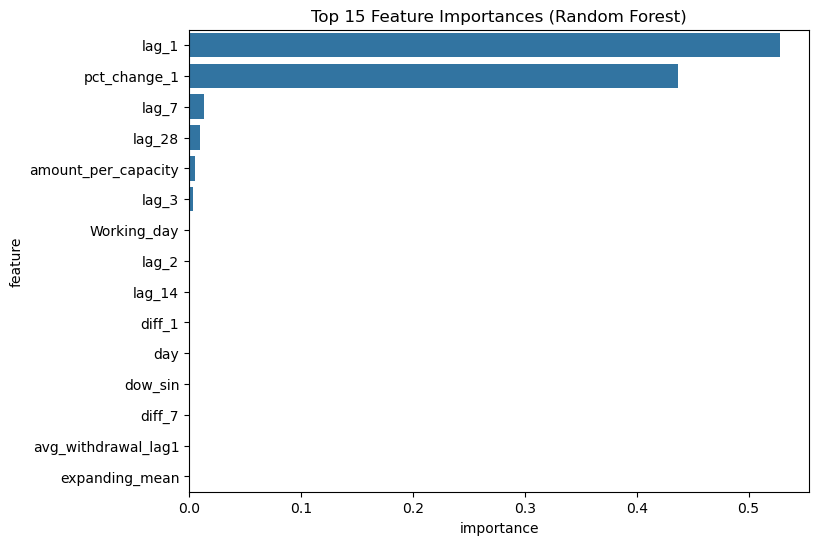

In [73]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

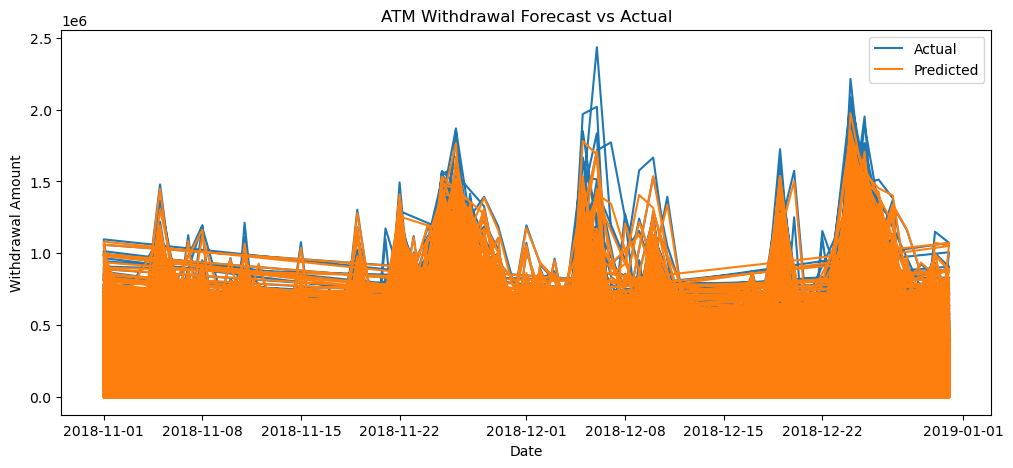

In [69]:
plt.figure(figsize=(12,5))

plt.plot(df_model.loc[test_idx, "Date"], y_true, label="Actual")
plt.plot(df_model.loc[test_idx, "Date"], pred, label="Predicted")

plt.legend()
plt.title("ATM Withdrawal Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Withdrawal Amount")

plt.show()

### Tuning

In [80]:
tune_features = [
    "lag_1",
    "pct_change_1",
    "lag_7",
    "lag_28",
    "amount_per_capacity",
    "Working_day",
    "capacity",
    "dow_sin",
    "dow_cos"
]

X_tune = df_model[tune_features]

X_train_tune = X_tune.loc[train_idx]
X_test_tune  = X_tune.loc[test_idx]

In [81]:
tscv = TimeSeriesSplit(n_splits=5)

In [82]:
param_dist = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [8, 10, 12, 14, 16, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5],
}

In [83]:
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [8, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [84]:
print("Best Params:")
print(rf_search.best_params_)

Best Params:
{'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}


In [85]:
rf_best = rf_search.best_estimator_
evaluate(rf_best, X_train, y_train, X_test, y_test, "Random Forest (Tuned)")


Random Forest (Tuned)
MAE : 5,875.65
RMSE: 35,542.56
R²  : 0.9716


### Export

In [86]:
import joblib

joblib.dump({
    "model": rf_best,
    "features": X.columns.tolist()
}, "../models/rf_model.pkl")

['../models/rf_model.pkl']